# Modellare il rischio di insolvenza creditizia non lineare con spline di regressione

## Sintesi esecutiva

Il team di rischio di una banca retail ha bisogno di sapere *dove* il rischio di insolvenza diventa non lineare prima di impegnarsi in una scorecard di produzione. Invece di suddividere manualmente in classi ogni variabile, il team stima un **modello additivo generalizzato** con `PROC GAM`: ogni caratteristica del debitore entra come spline di lisciamento cubica, così che le relazioni a soglia e a U vengono stimate direttamente dai dati sulla scala logit. Su un portafoglio sintetico deliberatamente avverso di 100 prestiti (39% in insolvenza), il modello additivo a spline riduce la devianza da 133,75 (solo intercetta) a 61,69 - un calo di 72,06 - per un AIC del modello di 81,69. La spline stimata del rapporto debito/reddito porta il coefficiente più grande (4,34), e la suddivisione in classi dell'esito grezzo conferma la struttura progettata: il rischio di insolvenza è marcatamente **a U rispetto all'età** (66,7% tra i debitori più giovani, 4,8% in età media, 86,4% tra i più anziani) e cresce con la leva finanziaria.

## Fonti dei dati

| Dataset | Righe | Ruolo | Variabili chiave | Descrizione |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Input del modello | `default` (target 0/1), `age`, `dti` (debito/reddito), `utilization` (uso del credito rotativo) | Richieste sintetiche di prestiti retail. Il vero log-odds di insolvenza è costruito con non linearità deliberate - un effetto dell'età a U e soglie a gomito nel rapporto debito/reddito e nell'utilizzo - poi campionato secondo Bernoulli. Generato inline con `call streaminit(20260531)` e `rand()`; nessun file esterno. |

Questo ambiente è privo di licenza, quindi l'output è limitato a 100 osservazioni. Lo scenario è dimensionato per quel limite: il segnale è reso abbastanza forte perché un modello additivo a spline con tre termini possa recuperare le forme da 100 prestiti.

# Perché le spline per il rischio di credito

Le scorecard tradizionali si basano sulla regressione logistica con variabili suddivise manualmente in classi (weight-of-evidence / information-value). Funziona, ma costringe l'analista a *indovinare* dove si trovano le soglie di rischio e la curvatura. Un **modello additivo generalizzato (GAM)** sostituisce ogni termine lineare con una funzione liscia - qui una spline di lisciamento cubica con tre gradi di libertà - così che la forma della curva viene stimata anziché assunta. `PROC GAM` stima queste funzioni lisce sulla scala logit per un target binario, esattamente il contesto di un modello di probabilità di insolvenza.

In questo notebook interpretiamo il ruolo del team di rischio di una banca retail. Noi:

1. Generiamo un portafoglio di prestiti sintetico la cui **vera** probabilità di insolvenza è genuinamente non lineare (un effetto dell'età a U ed effetti a soglia nel rapporto debito/reddito e nell'utilizzo).
2. Stimiamo un modello additivo a spline binomiale/logit e leggiamo la sua devianza, l'AIC e i coefficienti per ogni funzione liscia.
3. Confermiamo le forme recuperate suddividendo in classi l'esito grezzo di insolvenza e tracciandolo con `PROC SGPLOT`.

Nulla di ciò richiede dati esterni o una connessione di rete.

## Passo 1 - Costruire un portafoglio di prestiti sintetico

Simuliamo 100 richieste di prestiti. Ogni debitore ha tre caratteristiche. Il **log-odds di insolvenza** è costruito da componenti intenzionalmente non lineari così da avere una verità di riferimento nota che il modello a spline deve recuperare:

- **Age** - una forma a U: il rischio di insolvenza è elevato per i debitori molto giovani e molto anziani ed è minimo in età media. Lo codifichiamo come un termine di età al quadrato e centrato.
- **DTI** - un effetto a soglia: poco impatto finché il rapporto debito/reddito non supera ~0,35, poi il rischio sale (un gomito a un lato).
- **Utilization** - un secondo gomito a ~0,60 della linea di credito rotativo.

Il flag binario `default` viene poi estratto da una distribuzione di Bernoulli con quella probabilità. L'intercetta è impostata abbastanza bassa perché siano le non linearità progettate, non un livello base elevato, a guidare le insolvenze - si tratta di un portafoglio deliberatamente avverso e ad alto rischio, scelto in modo che le forme siano visibili in soli 100 prestiti.

In [1]:
DATI loans;
   CHIAMARE streaminit(20260531);

   FARE id = 1 FINO_A 100;
      /* ---- caratteristiche del richiedente ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 anni    */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debito/reddito   */
      utilization = rand("UNIFORM");               /* 0 .. 1 del limite */

      /* ---- VERO log-odds non lineare di insolvenza ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* forma a U        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* soglia (hinge)   */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* soglia (hinge)   */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      RIMUOVERE age_c eta_age eta_dti eta_util eta p_true;
      USCITA;
   FINE;
ESEGUIRE;

PROCEDURA MEDIE DATI=loans n mean MIN MAX maxdec=3;
   VARIABILE default AGE dti utilization;
   ETICHETTA default="Insolvenza" AGE="Età"
         dti="Rapporto debito/reddito"
         utilization="Utilizzo del credito";
ESEGUIRE;


                                                  The MEANS Procedure

 Variable     Label                           N           Mean     Minimum     Maximum
 -------------------------------------------------------------------------------------
 default      Insolvenza                    100          0.390       0.000       1.000
 AGE          Età                           100         44.993      18.342      69.646
 dti          Rapporto debito/reddito       100          0.312       0.059       0.590
 utilization  Utilizzo del credito          100          0.548       0.012       0.988
 -------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Il riepilogo di `PROC MEANS` conferma il portafoglio: un tasso complessivo di insolvenza del **39%** (un libro sotto stress e ad alto rischio), con età che va da 18 a 70, rapporto debito/reddito con media 0,31 e utilizzo con media 0,55 sull'intero intervallo 0-1. Con i dati a disposizione possiamo stimare il modello.

## Passo 2 - Stimare il modello additivo a spline

L'istruzione `MODEL` nomina la risposta binaria e racchiude ogni predittore in `spline(var, df=3)`, richiedendo una spline di lisciamento cubica con tre gradi di libertà ciascuna. Le opzioni:

- `event='1'` - modella la probabilità dell'evento di *insolvenza*, non del non-evento.
- `dist=binomial` - un target 0/1 stimato sulla scala logit, la scelta naturale per una probabilità di insolvenza.

`PROC GAM` riporta la **devianza** del modello e l'**AIC**, un coefficiente per ogni termine liscio e una tabella del modello di lisciamento che elenca i gradi di libertà spesi per componente.

In [2]:
TITOLO "Modello logistico additivo generalizzato dell'insolvenza dei prestiti";

PROCEDURA gam DATI=loans;
   MODELLO default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   ETICHETTA default="Insolvenza" AGE="Età"
         dti="Rapporto debito/reddito"
         utilization="Utilizzo del credito";
ESEGUIRE;

TITOLO;


                         Modello logistico additivo generalizzato dell'insolvenza dei prestiti                          


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Insolvenza
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spli


NOTE: Option TITLE changed to Modello logistico additivo generalizzato dell'insolvenza dei prestiti.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


La stima è forte. La **devianza nulla** di 133,75 (un modello con sola intercetta) scende a una **devianza residua di 61,69** una volta aggiunte le tre funzioni lisce - una riduzione di 72,06 - e l'**AIC del modello è 81,69**. Tra i termini lisci, la **spline del rapporto debito/reddito porta il coefficiente più grande (4,34)**, davanti alle spline dell'età e dell'utilizzo, identificando la leva finanziaria come il driver dominante del log-odds stimato. Ogni funzione liscia spende tre gradi di libertà, come richiesto. Il modello ha scoperto che queste relazioni sono non lineari senza che noi specificassimo una sola classe o un termine polinomiale.

## Passo 3 - Confermare le forme recuperate

Una funzione liscia stimata è convincente solo se corrisponde ai dati grezzi. Suddividiamo ogni debitore in classi per età e per rapporto debito/reddito, calcoliamo il tasso di insolvenza realizzato in ciascuna banda con `PROC MEANS` e lo tracciamo con `PROC SGPLOT`. Se il modello a spline dice il vero, l'esito suddiviso in classi dovrebbe tracciare la stessa forma a U e la stessa soglia stimate dal modello.

In [3]:
DATI binned;
   IMPOSTARE loans;
   LUNGHEZZA dti_band $9 age_band $5;

   SE_COND      dti < 0.20 ALLORA dti_band = "0.00-0.20";
   ALTRIMENTI SE_COND dti < 0.30 ALLORA dti_band = "0.20-0.30";
   ALTRIMENTI SE_COND dti < 0.40 ALLORA dti_band = "0.30-0.40";
   ALTRIMENTI SE_COND dti < 0.50 ALLORA dti_band = "0.40-0.50";
   ALTRIMENTI                    dti_band = "0.50+";

   SE_COND      AGE < 30 ALLORA age_band = "18-30";
   ALTRIMENTI SE_COND AGE < 40 ALLORA age_band = "30-40";
   ALTRIMENTI SE_COND AGE < 50 ALLORA age_band = "40-50";
   ALTRIMENTI SE_COND AGE < 60 ALLORA age_band = "50-60";
   ALTRIMENTI                  age_band = "60-70";
ESEGUIRE;

PROCEDURA MEDIE DATI=binned NWAY NOPRINT;
   CLASSE age_band;
   VARIABILE default;
   USCITA out=age_rate(RIMUOVERE=_type_ _freq_)
          n=n mean(default)=def_rate;
ESEGUIRE;

PROCEDURA MEDIE DATI=binned NWAY NOPRINT;
   CLASSE dti_band;
   VARIABILE default;
   USCITA out=dti_rate(RIMUOVERE=_type_ _freq_)
          n=n mean(default)=def_rate;
ESEGUIRE;

PROCEDURA STAMPARE DATI=age_rate noobs ETICHETTA;
   VARIABILE age_band n def_rate;
   ETICHETTA age_band="Fascia di età" n="Conti"
         def_rate="Tasso di insolvenza";
   FORMATO def_rate percent8.1;
ESEGUIRE;

PROCEDURA STAMPARE DATI=dti_rate noobs ETICHETTA;
   VARIABILE dti_band n def_rate;
   ETICHETTA dti_band="Fascia debito/reddito" n="Conti"
         def_rate="Tasso di insolvenza";
   FORMATO def_rate percent8.1;
ESEGUIRE;



 Fascia di età  Conti  Tasso di insolvenza
--------------  -----  -------------------
18-30              21                66.7%
30-40              19                10.5%
40-50              21                 4.8%
50-60              17                17.6%
60-70              22                86.4%

Fascia debito/reddito  Conti  Tasso di insolvenza
---------------------  -----  -------------------
0.00-0.20                 29                37.9%
0.20-0.30                 21                28.6%
0.30-0.40                 15                33.3%
0.40-0.50                 20                50.0%
0.50+                     15                46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Le bande d'età tracciano una U netta: il **66,7%** dei debitori sotto i 30 anni è in insolvenza, il tasso tocca il minimo del **4,8%** per la banda 40-50, poi risale all'**86,4%** per i debitori di 60 anni e oltre. Le bande del rapporto debito/reddito crescono complessivamente - dal quasi 40% nella banda più bassa a circa il 50% oltre un DTI di 0,40 - anche se con soli 100 prestiti i tassi per banda sono rumorosi, che è esattamente il motivo per cui la funzione liscia del modello (anziché un singolo taglio netto) è la sintesi più affidabile. I grafici sottostanti rendono visibili entrambe le forme.

### L'effetto dell'età è a U

Tracciare il tasso di insolvenza realizzato per banda d'età mostra la curvatura recuperata dalla spline: rischio elevato a entrambe le estremità dell'intervallo d'età, un profondo minimo in età media.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


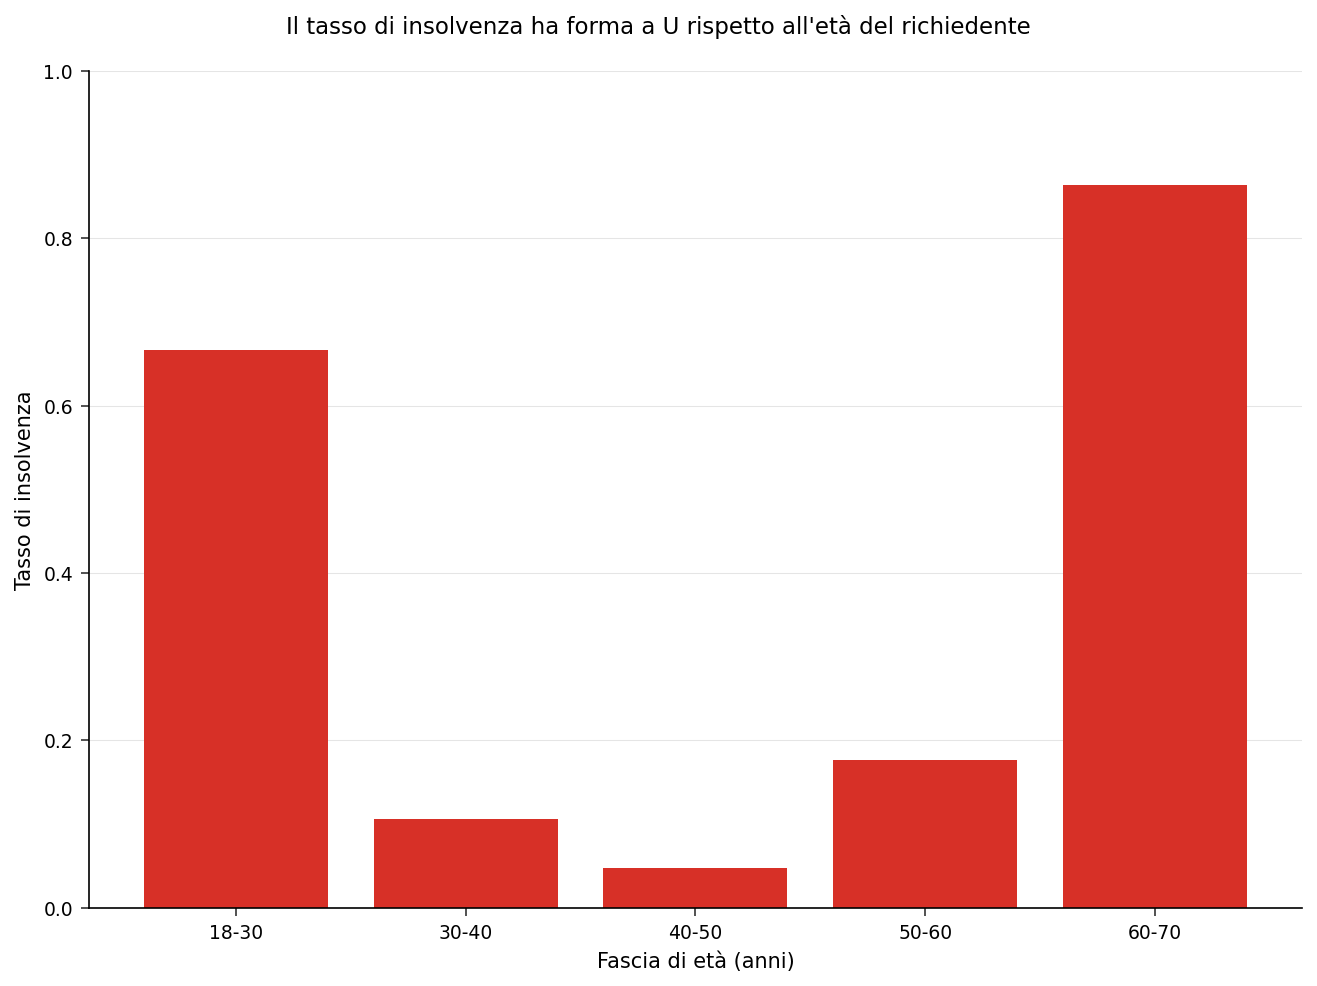

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=age_rate noautolegend;
   TITOLO "Il tasso di insolvenza ha forma a U rispetto all'età del richiedente";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ETICHETTA="Tasso di insolvenza" VALUES=(0 FINO_A 1 PER 0.2) grid;
   XAXIS ETICHETTA="Fascia di età (anni)";
ESEGUIRE;

TITOLO;
ODS GRAPHICS OFF;


### Il rischio cresce con la leva finanziaria

Le bande del rapporto debito/reddito tendono a crescere - i debitori più indebitati sono in insolvenza più spesso - coerentemente con la spline DTI dominante nel modello. Le bande centrali sono rumorose a questa dimensione campionaria, sottolineando perché la spline stimata è una guida più stabile di qualsiasi singolo taglio tracciato a mano.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


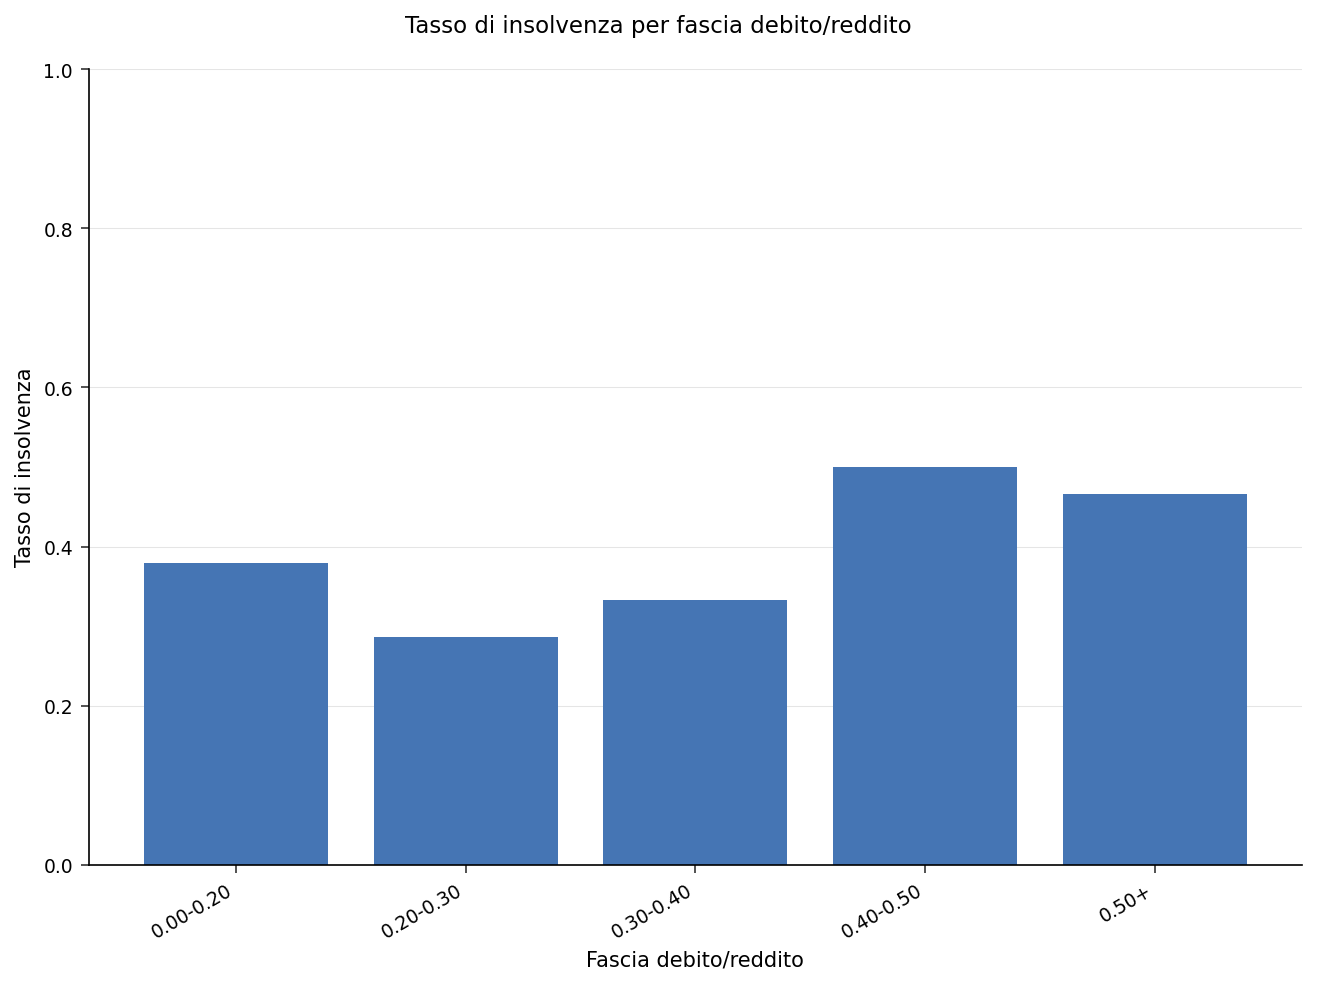

In [5]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=dti_rate noautolegend;
   TITOLO "Tasso di insolvenza per fascia debito/reddito";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ETICHETTA="Tasso di insolvenza" VALUES=(0 FINO_A 1 PER 0.2) grid;
   XAXIS ETICHETTA="Fascia debito/reddito";
ESEGUIRE;

TITOLO;
ODS GRAPHICS OFF;


## Interpretare i risultati

`PROC GAM` ha recuperato la struttura non lineare che abbiamo inserito nel portafoglio sintetico senza alcuna suddivisione manuale in classi né termini polinomiali:

- **Forte adattamento complessivo** - il modello additivo a spline porta la devianza da 133,75 fino a 61,69 (una riduzione di 72,06) per un AIC del modello di 81,69, su un libro con un tasso base di insolvenza del 39%.
- **La leva finanziaria domina** - la spline del rapporto debito/reddito porta il coefficiente più grande (4,34) dei tre termini, segnalando il DTI come principale driver del log-odds stimato.
- **Curvatura nell'età** - la suddivisione in classi dell'esito grezzo conferma una U da manuale: 66,7% di insolvenza nella banda sotto i 30 anni, un minimo del 4,8% a 40-50 e 86,4% per la banda dai 60 anni in su - la forma che una spline cubica cattura naturalmente ma che un singolo termine lineare per l'età mancherebbe completamente.
- **Onesto sul rumore** - a 100 prestiti i tassi per banda del rapporto debito/reddito oscillano, che è precisamente il caso a favore di una stima liscia rispetto a un taglio netto scelto a mano.

**Perché questo conta per il settore bancario:** le spline additive offrono a un team di rischio un modo rapido e automatico per rilevare dove una relazione è genuinamente non lineare prima di impegnarsi in una scorecard di produzione. Le funzioni lisce stimate sono direttamente interpretabili come curve di rischio - un premio d'età per giovani e anziani, una rampa per la leva finanziaria - e la devianza e l'AIC quantificano quanto quella flessibilità porti rispetto a un modello lineare piatto.